# Semana 7

In [3]:
import os
import time
from pymongo import MongoClient
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

# Limpieza de procesos anteriores
os.system("pkill -9 chrome")
os.system("pkill -9 chromedriver")
os.system("rm -rf /tmp/.com.google.Chrome.*")
print("Limpieza de procesos completada.")

NOMBRE_GRUPO     = "G1_Amazon_ValentinaArostica"
CATEGORIA_PRODUCTO = "Smartphones"
URL_BUSQUEDA     = "https://www.amazon.es/s?k=smartphones"

datos_finales = []
driver        = None

options = Options()
options.binary_location = "/usr/bin/google-chrome"
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")
options.add_argument("--disable-gpu")
options.add_argument("--window-size=1920,1080")
options.add_argument(
    "user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
    "AppleWebKit/537.36 (KHTML, like Gecko) "
    "Chrome/120.0.0.0 Safari/537.36"
)

try:
    driver = webdriver.Chrome(options=options)
    print("Navegador iniciado correctamente.")
    print("Puedes verlo en: http://localhost:6080/vnc.html")

    # Navegar a Amazon
    print(f"\nAbriendo: {URL_BUSQUEDA}")
    driver.get(URL_BUSQUEDA)


    print("\n" + "=" * 60)
    print("ACCIÓN REQUERIDA — INTERVENCIÓN MANUAL")
    print("=" * 60)
    print("1. Ve a http://localhost:6080/vnc.html")
    print("2. Verifica si aparece CAPTCHA o banner de cookies.")
    print("   - Banner de cookies → haz clic en Aceptar")
    print("   - CAPTCHA → resuélvelo manualmente")
    print("3. Cuando veas el listado de smartphones, vuelve aquí.")
    print("=" * 60)
    input("\nPresiona ENTER cuando estés lista para continuar...")

    print("\nVerificando estado de la página...")

    if "robot" in driver.title.lower() or "captcha" in driver.title.lower():
        print("BLOQUEO REAL detectado en el título de la página.")
        print("  Resuelve el CAPTCHA en la ventana VNC y vuelve aquí.")
        input("Presiona ENTER cuando hayas resuelto el CAPTCHA...")
    else:
        print(f"Sin bloqueo real. Título de página: '{driver.title}'")

    # Verificación adicional en el HTML (puede tener falsos positivos)
    html_check = driver.page_source.lower()
    if "captcha" in html_check or "unusual activity" in html_check:
        print("ADVERTENCIA: palabras de bloqueo detectadas en el HTML "
              "(puede ser falso positivo en scripts internos).")
    else:
        print("HTML verificado: sin señales de bloqueo.")

    # EXTRACCIÓN DE DATOS 
    print("\nIniciando extracción de datos...")
    time.sleep(5)

    WebDriverWait(driver, 20).until(
        EC.presence_of_all_elements_located(
            (By.CSS_SELECTOR, "div[data-component-type='s-search-result']")
        )
    )

    bloques = driver.find_elements(
        By.CSS_SELECTOR, "div[data-component-type='s-search-result']"
    )
    print(f"Bloques de productos encontrados: {len(bloques)}")

    for bloque in bloques:
        try:
            nombre = bloque.find_element(By.TAG_NAME, "h2").text.strip()
            if not nombre:
                continue
            precio_texto  = bloque.find_element(By.CSS_SELECTOR, ".a-price-whole").text
            precio_limpio = precio_texto.replace(".", "").replace(",", "").strip()
            precio        = float(precio_limpio) if precio_limpio.isdigit() else 0.0

            datos_finales.append({
                "identificador": nombre,
                "valor":         precio,
                "categoria":     CATEGORIA_PRODUCTO,
                "grupo":         NOMBRE_GRUPO,
                "fecha_captura": time.strftime("%Y-%m-%d %H:%M:%S")
            })
        except:
            continue

    print(f"\nTotal de productos capturados: {len(datos_finales)}")
    print("-" * 60)
    for i, p in enumerate(datos_finales[:5], 1):
        print(f"{i}. {p['identificador'][:65]}")
        print(f"   Precio: €{p['valor']:.2f}")
    print("-" * 60)

except Exception as e:
    print(f"Error en Selenium: {e}")

finally:
    if driver is not None:
        driver.quit()
        print("Navegador cerrado correctamente.")

# GUARDAR EN MONGODB 
try:
    client    = MongoClient("bigdata_mongodb", 27017, serverSelectionTimeoutMS=5000)
    db        = client["TiendaBigData"]
    coleccion = db["AmazonSmartphones"]

    if datos_finales:
        coleccion.insert_many(datos_finales)
        total = coleccion.count_documents({"grupo": NOMBRE_GRUPO})
        print(f"Datos guardados en MongoDB: TiendaBigData.AmazonSmartphones")
        print(f"Total en colección para este grupo: {total}")
    else:
        print("No hay datos para guardar.")

except Exception as e:
    print(f"Error MongoDB: {e}")

Limpieza de procesos completada.
Navegador iniciado correctamente.
Puedes verlo en: http://localhost:6080/vnc.html

Abriendo: https://www.amazon.es/s?k=smartphones

ACCIÓN REQUERIDA — INTERVENCIÓN MANUAL
1. Ve a http://localhost:6080/vnc.html
2. Verifica si aparece CAPTCHA o banner de cookies.
   - Banner de cookies → haz clic en Aceptar
   - CAPTCHA → resuélvelo manualmente
3. Cuando veas el listado de smartphones, vuelve aquí.

Verificando estado de la página...
Sin bloqueo real. Título de página: 'Amazon.es : smartphones'
HTML verificado: sin señales de bloqueo.

Iniciando extracción de datos...
Bloques de productos encontrados: 60

Total de productos capturados: 55
------------------------------------------------------------
1. XIAOMI POCO X8 Pro MAX Smartphone 12+256GB, Dimensity 9500s, 8500
   Precio: €459.00
2. Google Pixel 10 Pro - Free Android Smartphone with Gemini, Triple
   Precio: €899.00
3. Google Pixel 10 Pro XL - Free Android Smartphone with Gemini, Tri
   Precio: €999.

---
Entorno Visual (VNC)

Captura de pantalla del navegador visible en `http://localhost:6080/vnc.html` durante la ejecución del scraper.

![Captura Amazon.png](<attachment:Captura Amazon.png>)
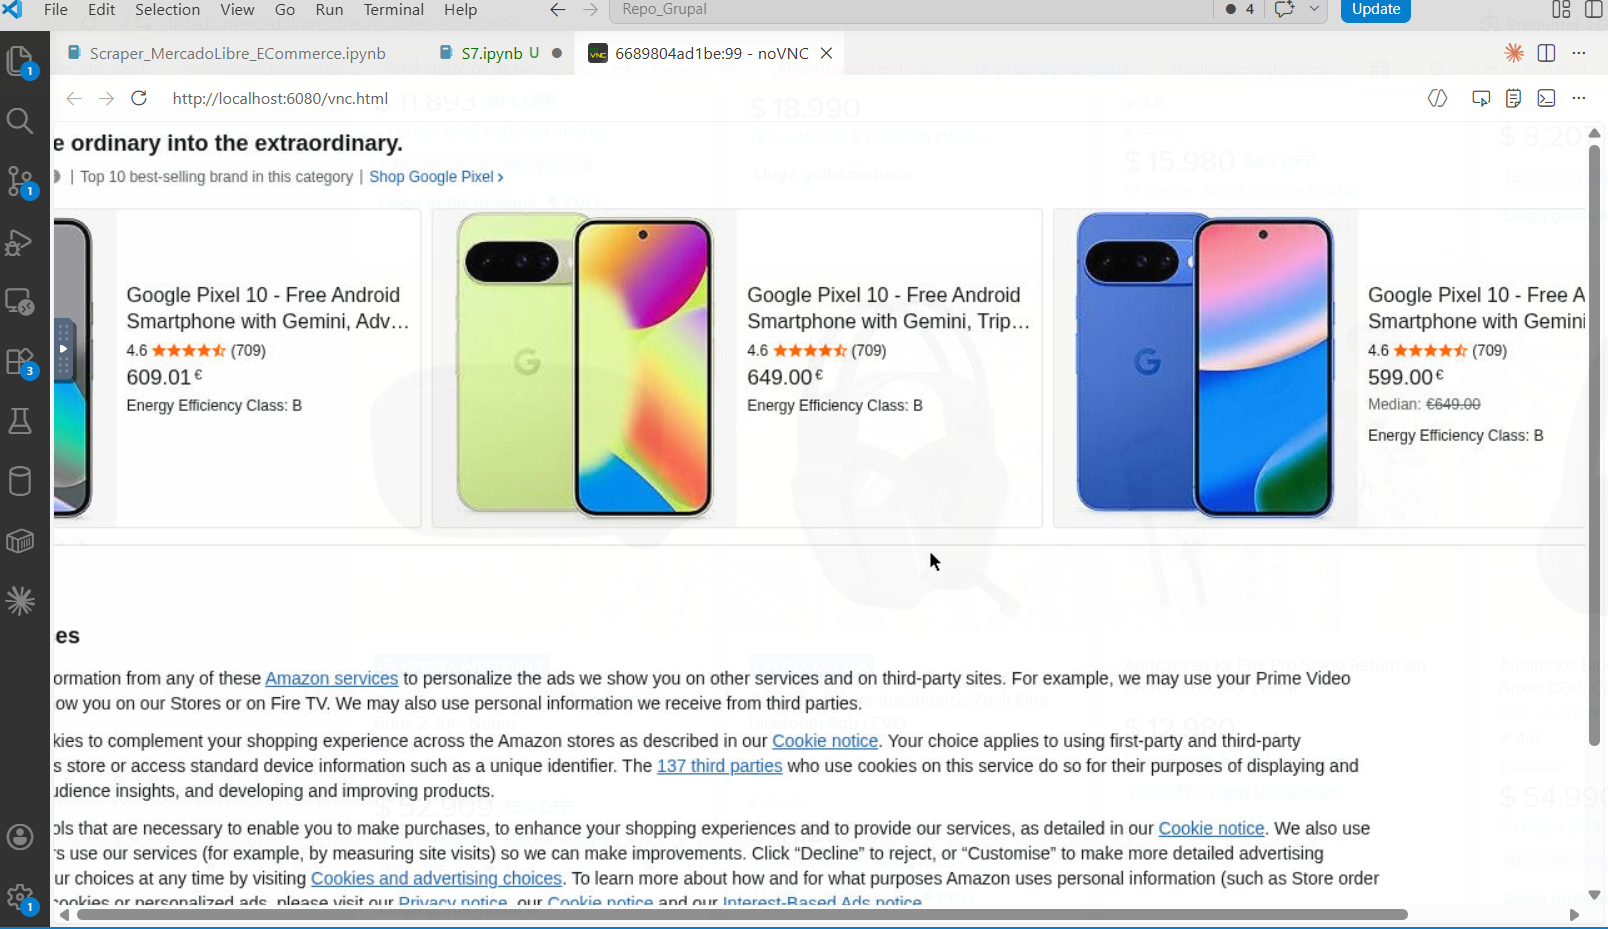

In [4]:
# Precio Promedio por Marca de Smartphones en Amazon
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, split, avg

spark = SparkSession.builder \
    .appName("Analisis_Amazon_S7_ValentinaArostica") \
    .config("spark.mongodb.read.connection.uri",
            "mongodb://bigdata_mongodb:27017/TiendaBigData.AmazonSmartphones") \
    .config("spark.jars.packages",
            "org.mongodb.spark:mongo-spark-connector_2.12:10.1.1") \
    .getOrCreate()

df = spark.read.format("mongodb").load()

# Total de productos procesados 
total_productos = df.count()
print(f"Total de productos procesados: {total_productos}")

# Transformación: extraer la marca 
df_transformado = df.withColumn("marca", split(col("identificador"), " ")[0])

# Limpieza de outliers: filtrar precios erróneos (< €50)
df_validado = df_transformado.filter(col("valor") > 50)
print(f"Registros válidos tras filtrar outliers: {df_validado.count()}")

# Agregación: precio promedio por marca
reporte_marcas = df_validado.groupBy("marca").agg(
    avg("valor").alias("precio_promedio")
).orderBy(col("precio_promedio").desc())

print("\nPRECIO PROMEDIO POR MARCA (€):")
reporte_marcas.show(truncate=False)

spark.stop()

Total de productos procesados: 165
Registros válidos tras filtrar outliers: 165

PRECIO PROMEDIO POR MARCA (€):
+---------+------------------+
|marca    |precio_promedio   |
+---------+------------------+
|Google   |639.0             |
|OnePlus  |597.0             |
|Samsung  |581.75            |
|TCL      |378.0             |
|XIAOMI   |306.864406779661  |
|Redmi    |297.0             |
|Nothing  |249.0             |
|REDMI    |238.5             |
|Xiaomi   |178.0             |
|APEXEL   |169.0             |
|HOTWAV   |159.0             |
|Feiyu    |151.0             |
|Moto     |145.0             |
|Ulefone  |134.14285714285714|
|Motorola |120.5             |
|realme   |114.125           |
|Blackview|96.0              |
|invens   |75.0              |
|4G       |75.0              |
|Economy  |55.0              |
+---------+------------------+

